# 🧪 LAB: Non-linear Dimensionality Reduction — t-SNE and UMAP

Over the past few weeks, we have explored how to handle non-linear relationships, mainly in the context of classification and regression tasks.

However, sometimes the first and most important step is to **visualize** the data — to gain intuition, spot structure, or detect outliers — even before any predictive modeling. You have already seen how PCA can help with this, but as we discussed this week, (ordinary) PCA is a linear method and may not capture non-linear patterns in the data effectively.

In this lab, you will learn about two popular **non-linear dimensionality reduction techniques** that are typically used for **data visualization**:  
- **t-SNE (t-distributed Stochastic Neighbor Embedding)**  
- **UMAP (Uniform Manifold Approximation and Projection)**

You will apply and compare these methods on two datasets:
- A simple biological dataset: Palmer Penguins
- A high-dimensional human genotype dataset from the 1000 Genomes Project (adapted from Diaz-Papkovich *et al.*, 2019)

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

---

In total, this lab assignment will be worth **100 points**.

--- 
**Submission notes**:

* Write down all group members' names, or at least the group name (if you have one and you previously provided it), in the first cell of the notebook.

* Verify that the notebook runs as expected and that all required outputs are included.


NAME(s) = ""

## 1. Background Reading (20 points)

Begin by reading **Section 5.3: t-SNE and UMAP for High-Dimensional Data** from the [*Machine Learning Hero* book](https://www.oreilly.com/library/view/machine-learning-hero/9781837025015/), which is available through UVA’s subscription to O’Reilly.

After reading, discuss with your group and respond to the following questions:

a. **Why might we choose t-SNE or UMAP over PCA for dimensionality reduction?**  
Briefly explain the limitations of PCA, and why non-linear methods like t-SNE and UMAP can be more effective in some contexts.

b. **Summarize the strengths and weaknesses of t-SNE and UMAP.**  
What are the key differences between the two methods? In what situations might you prefer one over the other?

c. **What are the main hyperparameters of each method, and what role do they play?**  
Describe how these hyperparameters affect the behavior and output of the algorithms.


YOUR TEXT HERE

## 2. Experiment with the Palmer Penguins Dataset (Toy Example) (50 points)

To get hands-on experience, you will begin by applying dimensionality reduction techniques to a small and interpretable dataset: Palmer Penguins.

Before you begin coding, read the official documentation for the following methods:

- [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) — from `sklearn.decomposition`
- [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) — from `sklearn.manifold`
- [UMAP](https://umap-learn.readthedocs.io/en/latest/basic_usage.html) — from the `umap-learn` package

After reviewing the documentation, complete the following tasks:

a. Load the Palmer Penguins dataset as demonstrated in the [UMAP documentation](https://umap-learn.readthedocs.io/en/latest/basic_usage.html#penguin-data).  

Select the following numerical features:

- `bill_length_mm`  
- `bill_depth_mm`  
- `flipper_length_mm`  
- `body_mass_g`

Then, **standardize** these features so that each has zero mean and unit variance.

In [43]:
# YOUR CODE HERE
# IMPORT STUFF
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# LOAD DATASET AND SET FEATURES AND PREDICTIVE FEATURE
df = pd.read_csv("https://raw.githubusercontent.com/allisonhorst/palmerpenguins/c19a904462482430170bfe2c718775ddb7dbb885/inst/extdata/penguins.csv")

# DROP NA
df = df.dropna(
    subset=[
        "bill_length_mm",
        "bill_depth_mm",
        "flipper_length_mm",
        "body_mass_g",
        "species"
    ]
)

X = df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]
y = df["species"]

# STANDARDIZE ENTIRE DATASET
standardizer = StandardScaler()
X_std = standardizer.fit_transform(X)

b. Apply **PCA**, **t-SNE**, and **UMAP** to reduce the selected features to **2 dimensions**.

Then, for each method:
- Create a **scatter plot** of the 2D projection.
- Use a different color to represent each **species** in the dataset.

This will help you visually assess how well each method separates the species in the reduced space.

*N.B.* You may need to first install `UMAP-learn`. Follow the [documentation](https://umap-learn.readthedocs.io/en/latest/index.html) for that.

<Axes: >

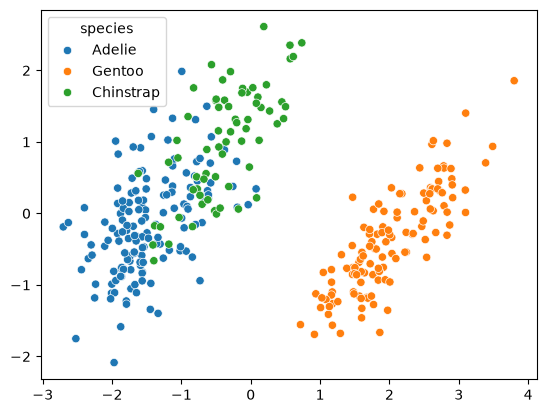

In [44]:
# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components = 2, random_state=1234)
X_pca = pca.fit_transform(X_std)
sns.scatterplot(x = X_pca[:,0], y = X_pca[:,1], hue = df["species"])

<Axes: >

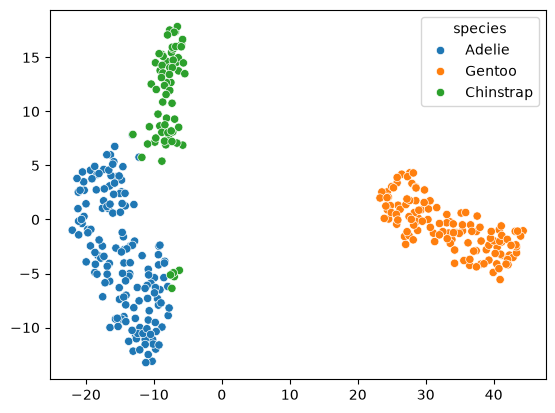

In [45]:
# t-SNE
import random
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=1234)
X_tsne = tsne.fit_transform(X_std)
sns.scatterplot(x = X_tsne[:, 0], y = X_tsne[:, 1], hue = df["species"])


/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: >

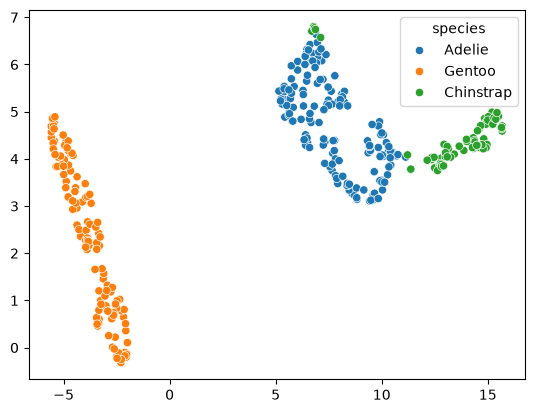

In [46]:
# UMAP
import umap
reducer = umap.UMAP(n_components = 2, random_state=1234)
X_umap = reducer.fit_transform(X_std)
sns.scatterplot(x = X_umap[: ,0], y = X_umap[:, 1], hue = df["species"])

c. Analyze the resulting plots and describe the main patterns you observe.

- Which method produces the most visually separable clusters?
- Are there any species that overlap in one method but not in others?
- What might explain these differences in how the data is projected?

Elaborate on your observations and compare the strengths and limitations of each method based on this toy example.


**All three methods are able to take a multi-dimensional dataset and squish it down to 2 components for analysis. PCA linearly combines all the features and come up with 2 principal directions/features. T-SNE and UMAP are both non-linear and can capture more complex patterns that PCA may miss. T-SNE focuses on visualizating local clusters of similar observations. Therefore it preserves the dataset's local structure so if neighbors were near each other before dimension reduction, they would still be near each other after. UMAP retains more of the global structure so different groups keep the same relationships with each other. It also prioritizes local relationships but unlike T-SNE, it also preserves some global structure.**\

**In the resulting plots, T-SNE and UMAP have the most visually separable clusters. In my opinion, T-SNE may be more separable intuitively. Adelies and Chinstraps tend to overlap the most. In all three, Adelie and Chinstrap have overlap while Gentoos are easily separated. In T-SNE and UMAP, there is one group of Chinstraps that are consistently grouped away from the larger group of Chinstraps. These 2 methods show groups and patterns that PCA cannot because they are non-linear. They are also more specialized to showing groupings.**\

**PCA can capture the overall variance, but it fails to capture non-linear patterns, which is why the grouping wasn't apparent in the PCA visualization. T-SNE is good at showing local relationships, so observations that were similar in the orignal dataset are closer together. However, it fails to consider global relationships. So distance here is not a good indicator of distance in the original dataset. UMAP solves this by consider the global relationships as well as local ones. Though it mostly focuses on grouping relationships.**

d. For **t-SNE** and **UMAP**, explore how different hyperparameter settings affect the resulting 2D projections.

- For **t-SNE**, vary the `perplexity` parameter (e.g., 5, 30, 50).
- For **UMAP**, vary the `n_neighbors` parameter (e.g., 5, 15, 50) and optionally `min_dist`.
- Keep `random_state` fixed across all runs so that differences between projections are due primarily to changes in the hyperparameters rather than random initialization.

For each configuration:
- Plot the resulting 2D projection.
- Use color to represent species.

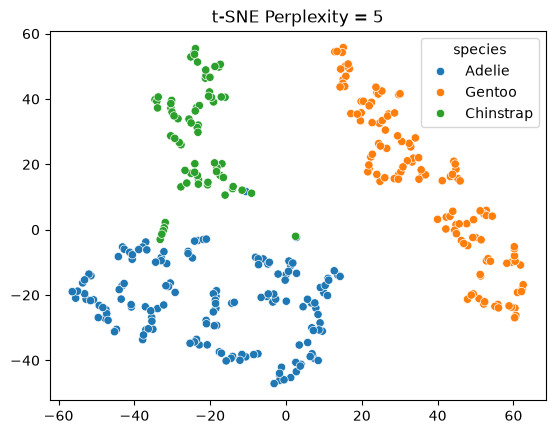

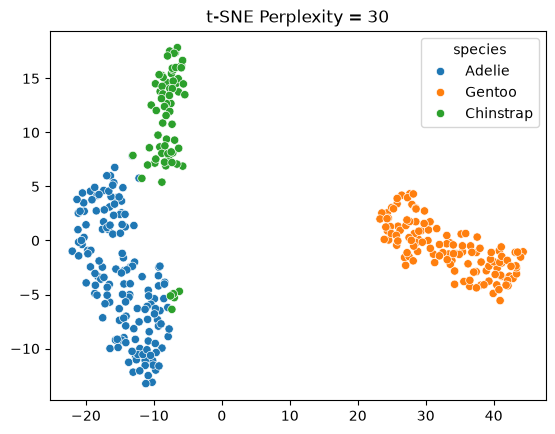

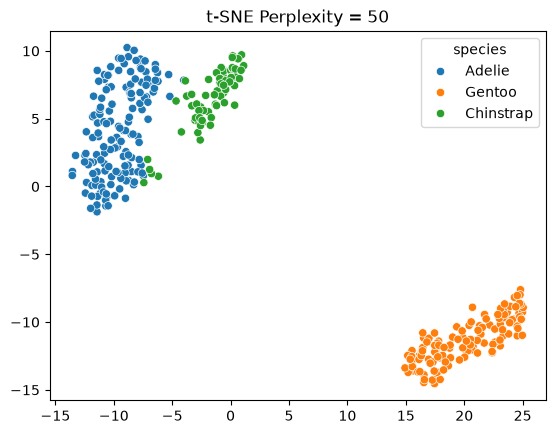

In [47]:
# T-SNE
from sklearn.manifold import TSNE
perplexities = [5, 30, 50]
tsne = TSNE()

for p in perplexities:
    tsne = TSNE(n_components = 2, perplexity= p, random_state = 1234)
    X_tsne_p = tsne.fit_transform(X_std)
    
    sns.scatterplot(x= X_tsne_p[:, 0], y=X_tsne_p[:, 1], hue=df["species"])
    plt.title(f"t-SNE Perplexity = {p}")
    plt.show()    

/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


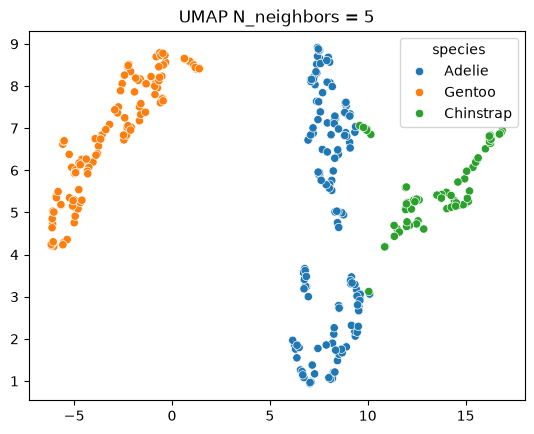

/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


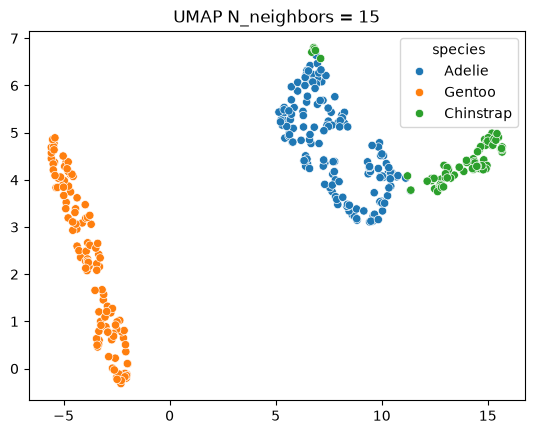

/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


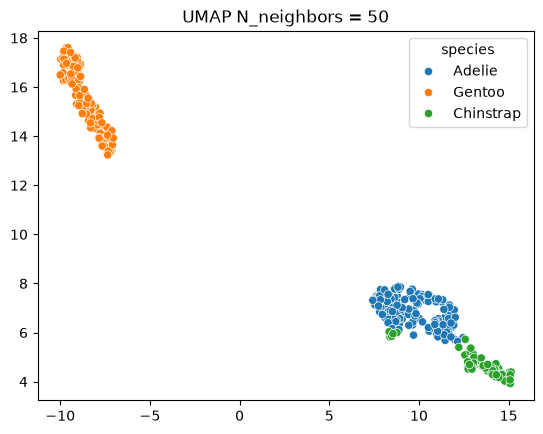

In [48]:
import umap

neighbors = [5, 15, 50]
for n in neighbors:
    reducer_n = umap.UMAP(n_components = 2, n_neighbors=n, random_state=1234)
    X_umap_n = reducer_n.fit_transform(X_std)
    sns.scatterplot(x = X_umap_n[: ,0], y = X_umap_n[:, 1], hue = df["species"])

    plt.title(f"UMAP N_neighbors = {n}")
    plt.show()


After generating the plots, describe the main changes you observe in the visualizations:
- How do the clusters shift, stretch, or separate as hyperparameters change?
- Which settings appear to better preserve the structure of the data?

Elaborate on your observations and support your discussion with specific visual examples.

**I changed all of them to contain random state 1234 because I wanted to only focus on the changes in n neighbors and perplexity. In T-SNE, the groupings became more tight. When perplexity was low (p = 5), the scatter plot was more scattered and random. Increasing the perplexity pushed the points together. It is almost like a vertical squeeze when it was at the highest perplexity (p = 50). For UMAP, the groups physcially shifted rather than compressed. When number of neighbors was low (n = 5), it had 3 separable groups. However, as neighbors increased (n = 50), the groups more and more merged together.**\

**I think TSNE preserves the structure of the data the most. It simply compresses the data points closer together, but preserves the groupings. In UMAP, the groupings merged together as neighbors increased.**

## 3. Apply to Real Data (1000 Genomes Subset) (25 points)

Your goal in this section is to try to create a figure similar to Figure 1 of the Diaz-Papkovich *et al.* (2019) paper, using a subset of genotype data from the 1000 Genomes Project.

To do so, complete the following steps:

a. Load the genotype dataset accompanying this lab, where each row corresponds to an individual, and each column to a genetic variant. Load also the provided population labels for each individual. 

b. **Standardize** the features (i.e., transform the genotype values to have zero mean and unit variance).

c. Apply **PCA**, **t-SNE**, and **UMAP** to reduce the data to 2 dimensions. You may use the default values for the rest of hyperparameters in these techniques. 

d. Create **scatter plots** of the resulting projections, coloring each point according to its **population group**.

e. Reflect on the following questions:
- Explain what you observe in each case. Additionally, which method appears to provide the best visual separation of the population into distinct groups? Elaborate on why this might be the case, based on what you know about each method.
- What changes if you first reduce the data to the **top 25 PCA components**, and then apply t-SNE or UMAP?
- In your opinion, what are the trade-offs between **interpretability** (e.g., preservation of local and global structure) and **performance** (e.g., visual separation of known populations and computational time) when using these dimensionality reduction methods?

Please elaborate on your answers and use the plots to support your discussion.

a. Load the genotype dataset accompanying this lab, where each row corresponds to an individual, and each column to a genetic variant. Load also the provided population labels for each individual. 

In [49]:
# A)
X_genome = np.load("genome_data_lab3.npy")
pop = pd.read_csv("population_labels_lab3.txt", header=None)[0]

b. **Standardize** the features (i.e., transform the genotype values to have zero mean and unit variance).

In [50]:
# B)
from sklearn.impute import SimpleImputer

# Impute missing values to the column mean
X_genome = SimpleImputer(missing_values=-1).fit_transform(X_genome)
X_genome_std = StandardScaler().fit_transform(X_genome)

c. Apply **PCA**, **t-SNE**, and **UMAP** to reduce the data to 2 dimensions. You may use the default values for the rest of hyperparameters in these techniques. 

In [51]:
# C)
reducers = {
    "PCA": PCA(n_components=2, random_state=1234),
    "t-SNE": TSNE(random_state=1234),
    "UMAP": umap.UMAP(random_state=1234),
}

embeddings = {}
for name, reducer in reducers.items():
    embeddings[name] = reducer.fit_transform(X_genome_std)

print(f"Variance explained by PC1 + PC2: {reducers['PCA'].explained_variance_ratio_.sum():.3f}")

/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Variance explained by PC1 + PC2: 0.124


d. Create **scatter plots** of the resulting projections, coloring each point according to its **population group**.

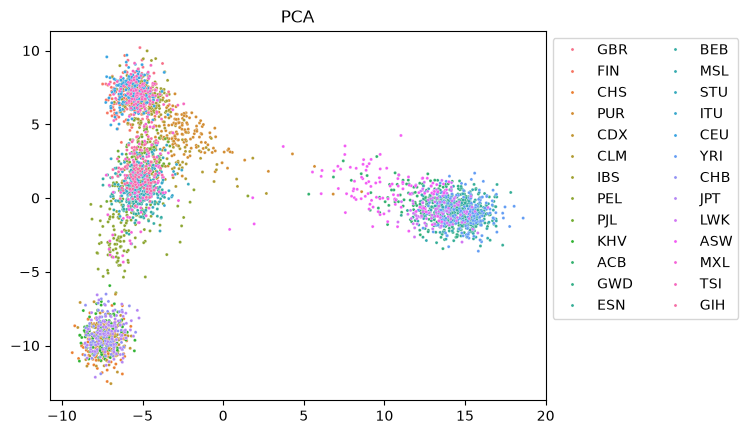

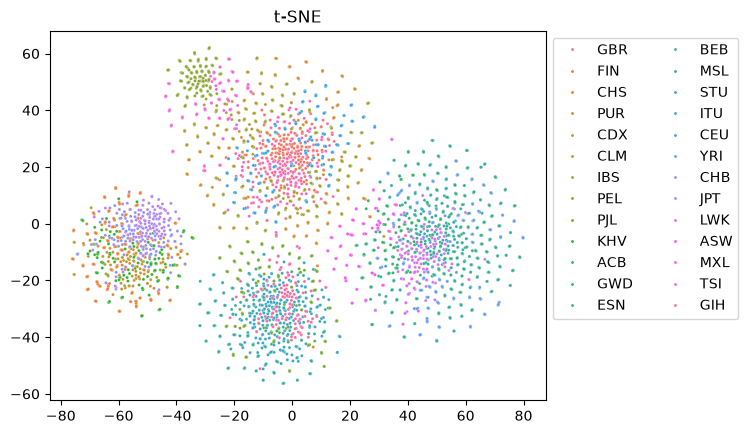

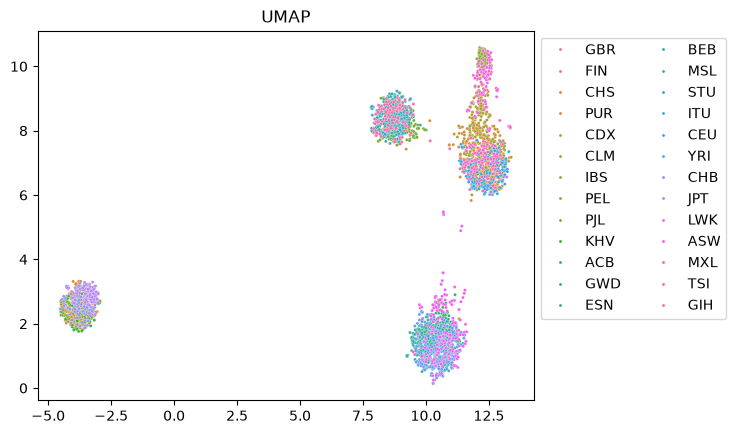

In [54]:
# D)
for name, X_2d in embeddings.items():
    sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=pop, palette="husl", s=5)
    plt.title(name)
    plt.legend(bbox_to_anchor=(1, 1), ncol=2)
    plt.show()

e. Reflect on the following questions:
- Explain what you observe in each case. Additionally, which method appears to provide the best visual separation of the population into distinct groups? Elaborate on why this might be the case, based on what you know about each method.

PCA: There are 4-5 main groups. The African populations are one big cluster off to the right by themselves, and the rest are on the left stacked on top of each other. We can see East Asia is on the bottom, South Asian is in the middle, and Europeans are on top. We can also see that ASW and ACB are spread out between the African cluster and the rest too, and the American popiulations are spread out between the Europeans and the other groups too. So basically PCA shows these big groups generally, but they also bleed into each other.

t-SNE: There are 5 separate blobs here, so it separates groups a little better than PCA. But the points within the blobs are pretty spread out .We can see the American populations are scattered around the European blob rather than being their own separate group.

UMAP: Similar to t-SNE, it has 5 groups but it is way tighter groups with a lot of space between each group. The American populations come off the European cluster sort of tailed off rather than being fully crossed into it like t-SNE and PCA.

UMAP gives the best visual separation. This is because PCA is linear and only shows the 2 directions with the most variance, so it can't really pull the groups apart. t-SNE and UMAP are both non-linear and focus on keeping each point close to its nearest neighbors, so similar people get grouped together. We can see that UMAP packs those neighbors together closer than t-SNE does, and keeps a bit more separation of groups.

- What changes if you first reduce the data to the **top 25 PCA components**, and then apply t-SNE or UMAP?

/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


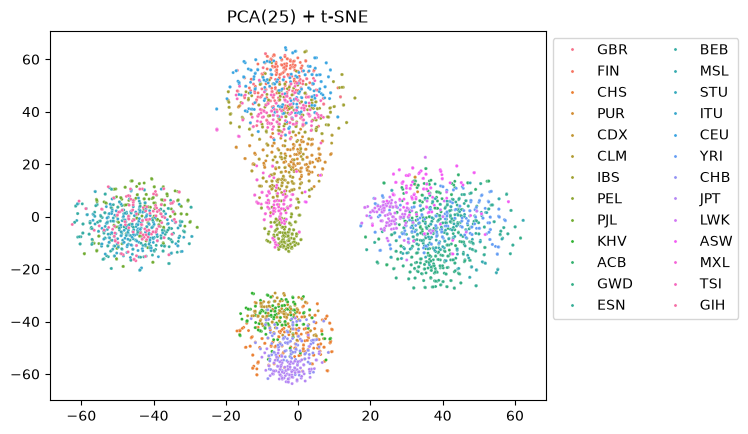

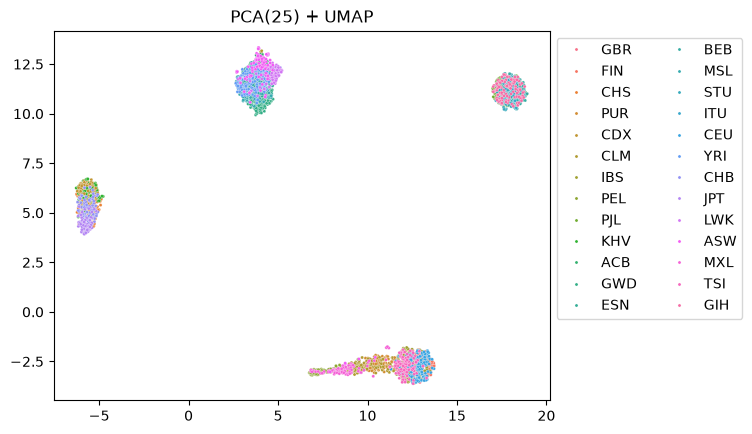

In [56]:
# E2)
X_pca25 = PCA(n_components=25, random_state=1234).fit_transform(X_genome_std)

embeddings_pca25 = {
    "PCA(25) + t-SNE": TSNE(random_state=1234).fit_transform(X_pca25),
    "PCA(25) + UMAP": umap.UMAP(random_state=1234).fit_transform(X_pca25)
}

for name, X_2d in embeddings_pca25.items():
    sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=pop, palette="husl", s=5)
    plt.title(name)
    plt.legend(bbox_to_anchor=(1, 1), ncol=2)
    plt.show()

t-SNE: Now the groups get a lot cleaner. The American populations are now their own group coming down from the European group instead of being scattered around the group. We can also see some splitting inside the East Asian group now too which we couldn't see before in the t-SNE.

UMAP: The groups are even tighter now than before. The America tail is thicker, but still extremely compact and not as long anymore. The East Asia cluster also starts to split a little.

So doing PCA first into the 25 components helps make the other methods, t-SNE and UMAP, a lot cleaner and we can see more structure inside the larger groups.

- In your opinion, what are the trade-offs between **interpretability** (e.g., preservation of local and global structure) and **performance** (e.g., visual separation of known populations and computational time) when using these dimensionality reduction methods?

PCA is the easiest to interpret since the axes are the directions with the most variance, and the distances between the blobs are also real distance. It's also the fastest, but shows the least visual separation among the groups.

t-SNE and UMAP separate the blobs much better, but they're harder to interpret since the axes don't mean anything, and the size of the blobs and distances between them can't be trusted as much. t-SNE mostly keeps the same local structure, while UMAP is more of a global structure. They're also both slower than PCA and can change depending on what hyperparams we choose.

## 4. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

YOUR TEXT HERE